# 2D Overlapping Domain Decomposition — Schwarz Alternating PINN
## SRIP 2026 — IIT Gandhinagar | DD-ANN Phase 4

**Solves:** $-(\partial^2 u/\partial x^2 + \partial^2 u/\partial y^2) = f(x,y)$ on $[0,1]^2$

---

## Domain Split

```
y
1 ┌──────────────────┬─────────┐
  │                  │  OVER-  │
  │       Ω₁         │  LAP    │    Ω₂
  │  [0,x_b]×[0,1]  │[x_a,x_b]│  [x_a,1]×[0,1]
  │                  │         │
0 └──────────────────┴─────────┘
  0               x_a x_b      1   x
```

## Key Differences vs 1D Schwarz

| Aspect | 1D Schwarz | **2D Schwarz** |
|--------|-----------|----------------|
| Interface | 2 points | 2 vertical **lines** |
| BC exchange | 1 scalar | **N values along interface line** |
| Global BCs | 2 endpoints | **3 edges per subdomain** |
| Extra loss term | PDE + BC | PDE + global BC + **interface BC** |
| Convergence metric | Point difference | **L2 norm over overlap rectangle** |
| Visualization | Line plot | **Heatmaps + 2D contour plots** |

## Schwarz Iteration Steps

At each iteration $k$:

**Step 1 — PINN₁** on $\Omega_1=[0,x_b]\times[0,1]$:
$$\text{Interface BC (right): } u_1(x_b, y) = u_2^{(k)}(x_b, y) \leftarrow \text{evaluate PINN}_2 \text{ along } x=x_b$$

**Step 2 — PINN₂** on $\Omega_2=[x_a,1]\times[0,1]$:
$$\text{Interface BC (left): } u_2(x_a, y) = u_1^{(k+1)}(x_a, y) \leftarrow \text{evaluate PINN}_1 \text{ along } x=x_a$$

**Step 3 — Monitor:**
$$\text{Overlap Error}^{(k)} = \left\|u_1 - u_2\right\|_{L^2(\Omega_\text{overlap})}$$

## Four Test Problems

| # | PDE | Exact $u$ | BCs |
|---|-----|----------|-----|
| 1 | $-\Delta u = 2\pi^2\sin(\pi x)\sin(\pi y)$ | $\sin(\pi x)\sin(\pi y)$ | $u=0$ |
| 2 | $-\Delta u = 2[x(1-x)+y(1-y)]$ | $x(1-x)y(1-y)$ | $u=0$ |
| 3 | $-\Delta u = 8\pi^2\sin(2\pi x)\sin(2\pi y)$ | $\sin(2\pi x)\sin(2\pi y)$ | $u=0$ |
| 4 | $-\Delta u = -3e^{x+y}$ | $e^{x+y}$ | $u=e^{x+y}$ |

## Section 1 — Imports & Reproducibility

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print(f"PyTorch {torch.__version__} | Device: {device}")

PyTorch 2.12.0+cpu | Device: cpu


## Section 2 — Network Architecture & 2D Laplacian

Same **4-layer × 64-neuron Tanh MLP** as `pinn_2d.py`.
Input: $(x,y)$ — shape $(N,2)$. Output: $u(x,y)$ — shape $(N,1)$.

The Laplacian $\Delta u = \partial^2u/\partial x^2 + \partial^2u/\partial y^2$ is computed
via **6 autodiff calls** (same as `pinn_2d.py`):
1. Forward → $u$
2. Grad → $\nabla u = (\partial u/\partial x,\ \partial u/\partial y)$
3. Grad of x-component → $\partial^2u/\partial x^2$
4. Grad of y-component → $\partial^2u/\partial y^2$
5. Sum → $\Delta u$

In [2]:
class PINN2D(nn.Module):
    """
    Standard MLP for 2D PINN.
    Input  : (x, y) → (N, 2)
    Output : u(x,y) → (N, 1)
    Uses SOFT BCs (all boundary conditions enforced via penalty loss).
    Soft BCs are used here because the interface value changes every
    Schwarz iteration — hard BC lifting would require re-building the
    network each time, which is impractical.
    """
    def __init__(self, hidden_layers=4, hidden_size=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))
        self.network = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, xy):
        return self.network(xy)


def create_model():
    return PINN2D(hidden_layers=4, hidden_size=64).to(device)


def compute_laplacian_2d(model, xy):
    """
    Compute Δu = ∂²u/∂x² + ∂²u/∂y² at points xy.
    xy: (N,2) with requires_grad=True (set internally).
    Returns (u, laplacian) both shape (N,1).
    """
    xy.requires_grad_(True)
    u = model(xy)                                        # (N,1)

    grad_u = torch.autograd.grad(
        u, xy,
        grad_outputs=torch.ones_like(u),
        create_graph=True, retain_graph=True
    )[0]                                                 # (N,2)

    d2u_dx2 = torch.autograd.grad(
        grad_u[:, 0:1], xy,
        grad_outputs=torch.ones_like(grad_u[:, 0:1]),
        create_graph=True, retain_graph=True
    )[0][:, 0:1]                                         # (N,1)

    d2u_dy2 = torch.autograd.grad(
        grad_u[:, 1:2], xy,
        grad_outputs=torch.ones_like(grad_u[:, 1:2]),
        create_graph=True, retain_graph=True
    )[0][:, 1:2]                                         # (N,1)

    return u, d2u_dx2 + d2u_dy2

print("PINN2D and Laplacian defined.")

PINN2D and Laplacian defined.


## Section 3 — Sampling Functions

### Interior sampling
Random points inside the subdomain rectangle $[x_{lo}, x_{hi}] \times [0,1]$.

### Global boundary sampling
Points on the edges of the subdomain that correspond to the **original problem boundary** (not the artificial interface):
- **Ω₁** = [0, x_b]×[0,1]: global edges are left ($x=0$), bottom ($y=0$), top ($y=1$)
- **Ω₂** = [x_a, 1]×[0,1]: global edges are right ($x=1$), bottom ($y=0$), top ($y=1$)

### Interface sampling — the key new step
Sample $N$ points $\{(x_{\text{if}},\ y_i)\}$ along the interface line.
Evaluate the **other network** at these points with `.detach()` (no gradients through other net):
```
u_target_i = net_other(x_if, y_i).detach()
```
These become the Dirichlet target values for the current network's interface BC loss.

In [3]:
def sample_interior_2d(n, x_lo, x_hi):
    """
    Uniform random points inside [x_lo, x_hi] × [0,1].
    Returns (N, 2) tensor on device.
    """
    x = x_lo + (x_hi - x_lo) * torch.rand(n, 1, device=device)
    y = torch.rand(n, 1, device=device)
    return torch.cat([x, y], dim=1)


def sample_global_boundary_2d(n_per_edge, x_lo, x_hi,
                               global_left, global_right):
    """
    Sample points on the GLOBAL (non-interface) boundary edges.

    global_left  = True → x=x_lo is a global boundary  (Ω₁: left at x=0)
    global_right = True → x=x_hi is a global boundary  (Ω₂: right at x=1)
    Bottom (y=0) and Top (y=1) are ALWAYS global boundaries.

    Returns xy tensor of shape (M, 2) containing all global boundary points.
    """
    n   = n_per_edge
    pts = []

    # Bottom: y=0, x ∈ [x_lo, x_hi]
    x_b = x_lo + (x_hi - x_lo) * torch.rand(n, 1, device=device)
    pts.append(torch.cat([x_b, torch.zeros(n, 1, device=device)], dim=1))

    # Top: y=1, x ∈ [x_lo, x_hi]
    x_t = x_lo + (x_hi - x_lo) * torch.rand(n, 1, device=device)
    pts.append(torch.cat([x_t, torch.ones(n, 1, device=device)], dim=1))

    # Left global edge: x=x_lo (only for Ω₁ where x_lo=0)
    if global_left:
        y_l = torch.rand(n, 1, device=device)
        pts.append(torch.cat([
            torch.full((n, 1), x_lo, device=device), y_l
        ], dim=1))

    # Right global edge: x=x_hi (only for Ω₂ where x_hi=1)
    if global_right:
        y_r = torch.rand(n, 1, device=device)
        pts.append(torch.cat([
            torch.full((n, 1), x_hi, device=device), y_r
        ], dim=1))

    return torch.cat(pts, dim=0)   # (M, 2)


def sample_interface_2d(n, x_interface, net_other):
    """
    Sample points along the interface line x = x_interface.
    Evaluate net_other at these points to get Dirichlet target values.

    CRITICAL: .detach() ensures gradients do NOT flow through net_other
    during the current network's backward pass.

    Returns:
        xy_if   : (N, 2) interface points
        u_target: (N, 1) target values from other network
    """
    y = torch.rand(n, 1, device=device)
    xy_if = torch.cat([
        torch.full((n, 1), x_interface, device=device),
        y
    ], dim=1)
    with torch.no_grad():
        u_target = net_other(xy_if)      # evaluate other PINN, no grad
    return xy_if, u_target


def compute_overlap_error(net1, net2, x_a, x_b, n=2000):
    """
    L2 norm of (u1 - u2) over the overlap region [x_a, x_b] × [0,1].
    This is the convergence metric for the Schwarz iteration.
    Should decrease to ~0 as iterations proceed.
    """
    x  = x_a + (x_b - x_a) * torch.rand(n, 1, device=device)
    y  = torch.rand(n, 1, device=device)
    xy = torch.cat([x, y], dim=1)
    with torch.no_grad():
        u1 = net1(xy)
        u2 = net2(xy)
    return torch.sqrt(torch.mean((u1 - u2) ** 2)).item()

print("Sampling functions defined.")
print("sample_interface_2d() exchanges BC info between the two PINNs.")

Sampling functions defined.
sample_interface_2d() exchanges BC info between the two PINNs.


## Section 4 — Loss Function

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{PDE}}}_{\text{interior residual}} + \lambda_{bc}\underbrace{\mathcal{L}_{\text{global}}}_{\text{fixed edges}} + \lambda_{bc}\underbrace{\mathcal{L}_{\text{interface}}}_{\text{from other PINN}}$$

Three terms vs two in single-domain PINN. The interface term is what couples the two networks and drives the Schwarz convergence.

In [4]:
def compute_loss_dd_2d(model, f_func, g_func,
                       xy_int,
                       xy_global, xy_if, u_if,
                       lambda_bc=100.0):
    """
    Compute total DD loss for one 2D subdomain.

    Args:
        model     : PINN for this subdomain
        f_func    : RHS f(xy) → (N,1)
        g_func    : global BC function g(xy) → (N,1)
        xy_int    : interior collocation points (N,2)
        xy_global : global boundary points (M,2)
        xy_if     : interface points (K,2)
        u_if      : target values at interface from other PINN (K,1)
        lambda_bc : penalty weight for both BC terms

    Returns:
        total (tensor), pde_val, global_bc_val, interface_val (floats)
    """
    # ── PDE residual loss ─────────────────────────────────────
    xy_g = xy_int.clone().detach().requires_grad_(True)
    _, lap = compute_laplacian_2d(model, xy_g)
    f_vals = f_func(xy_g)
    L_pde  = torch.mean((-lap - f_vals) ** 2)

    # ── Global boundary loss ──────────────────────────────────
    u_pred_global = model(xy_global)
    u_true_global = g_func(xy_global)
    L_global      = torch.mean((u_pred_global - u_true_global) ** 2)

    # ── Interface BC loss (Dirichlet from other PINN) ─────────
    u_pred_if = model(xy_if)
    L_if      = torch.mean((u_pred_if - u_if) ** 2)

    total = L_pde + lambda_bc * L_global + lambda_bc * L_if

    return (total,
            L_pde.item(),
            L_global.item(),
            L_if.item())

print("Loss function defined (3 terms: PDE + global BC + interface BC).")

Loss function defined (3 terms: PDE + global BC + interface BC).


## Section 5 — Subdomain Training Function

Trains one PINN on one subdomain for a fixed number of epochs.

Key parameter `global_left` / `global_right`:
- **Ω₁** (left subdomain): `global_left=True, global_right=False` → left edge x=0 is global BC, right edge x=x_b is interface
- **Ω₂** (right subdomain): `global_left=False, global_right=True` → right edge x=1 is global BC, left edge x=x_a is interface

In [5]:
def train_subdomain_2d(net, optimizer, f_func, g_func, net_other,
                       x_lo, x_hi, x_interface,
                       global_left, global_right,
                       epochs=1000,
                       n_interior=1500,
                       n_bc=80,
                       n_interface=100,
                       lambda_bc=100.0,
                       patience=200,
                       min_delta=1e-8):
    """
    Train one 2D subdomain PINN.

    Args:
        net          : PINN for this subdomain
        optimizer    : Adam optimizer (warm-started across iterations)
        f_func       : RHS function
        g_func       : global BC / exact solution function
        net_other    : the OTHER subdomain PINN (provides interface BC)
        x_lo, x_hi   : x-bounds of this subdomain
        x_interface  : x-coordinate of the artificial interface line
        global_left  : True if x=x_lo is a global boundary (Ω₁)
        global_right : True if x=x_hi is a global boundary (Ω₂)
        patience     : early stopping patience

    Returns:
        history (list of total loss per epoch), elapsed time (s)
    """
    history      = []
    best_loss    = float('inf')
    patience_ctr = 0
    t0           = time.perf_counter()

    for epoch in range(epochs):
        # ── Sample points ──────────────────────────────────────
        xy_int = sample_interior_2d(n_interior, x_lo, x_hi)

        xy_global = sample_global_boundary_2d(
            n_bc, x_lo, x_hi, global_left, global_right
        )

        xy_if, u_if = sample_interface_2d(n_interface, x_interface, net_other)

        # ── Compute loss and backprop ──────────────────────────
        total, pde_v, bc_v, if_v = compute_loss_dd_2d(
            net, f_func, g_func,
            xy_int, xy_global, xy_if, u_if,
            lambda_bc=lambda_bc
        )

        optimizer.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()

        history.append(total.item())

        # ── Early stopping ─────────────────────────────────────
        if total.item() < best_loss - min_delta:
            best_loss    = total.item()
            patience_ctr = 0
        else:
            patience_ctr += 1
        if patience_ctr >= patience:
            break

    return history, time.perf_counter() - t0

print("Subdomain trainer defined.")

Subdomain trainer defined.


## Section 6 — Schwarz Alternating DD Loop (Main Function)

This is the core of the 2D DD-PINN. Each iteration:
1. Trains PINN₁ with interface BC from current PINN₂
2. Trains PINN₂ with interface BC from updated PINN₁
3. Measures overlap error $\|u_1 - u_2\|_{L^2(\Omega_{\text{overlap}})}$

The **optimizer is warm-started** across iterations — same instance reused, so the networks build on previous training rather than starting from scratch each iteration.

In [6]:
def schwarz_dd_2d(f_func, g_func,
                  x_a=0.4, x_b=0.6,
                  schwarz_iters=5,
                  epochs_per_iter=1000,
                  n_interior=1500,
                  n_bc=80,
                  n_interface=100,
                  lambda_bc=100.0,
                  lr=1e-3,
                  patience=200,
                  verbose=True):
    """
    2D Overlapping Schwarz Alternating DD-PINN.

    Domain  : [0,1]²
    Ω₁      : [0,   x_b] × [0,1]  — left  subdomain (PINN₁)
    Ω₂      : [x_a, 1  ] × [0,1]  — right subdomain (PINN₂)
    Overlap : [x_a, x_b] × [0,1]

    Args:
        f_func        : RHS f(xy) → (N,1)
        g_func        : BC / exact solution g(xy) → (N,1)
        x_a, x_b      : overlap boundaries (x_a < x_b)
        schwarz_iters : number of Schwarz iterations
        epochs_per_iter: training epochs per subdomain per iteration
        lambda_bc     : BC penalty weight
        lr            : Adam learning rate

    Returns:
        net1, net2    : trained PINNs
        loss_history  : dict with 'omega1' and 'omega2' loss lists
        overlap_errors: list of overlap L2 errors per iteration
        total_elapsed : total training time (s)
    """
    # Networks and optimizers created ONCE, warm-started across iters
    net1  = create_model()
    net2  = create_model()
    opt1  = torch.optim.Adam(net1.parameters(), lr=lr)
    opt2  = torch.optim.Adam(net2.parameters(), lr=lr)

    loss_history   = {'omega1': [], 'omega2': []}
    overlap_errors = []
    iter_times     = []
    total_elapsed  = 0.0

    for it in range(schwarz_iters):
        if verbose:
            print(f"\n── Schwarz Iteration {it+1}/{schwarz_iters} ──")

        # ──────────────────────────────────────────────────────────
        # STEP 1: Train PINN₁ on Ω₁ = [0, x_b] × [0,1]
        #   global_left =True  → left edge x=0 uses global BC g
        #   global_right=False → right edge x=x_b uses PINN₂ interface BC
        # ──────────────────────────────────────────────────────────
        h1, t1 = train_subdomain_2d(
            net1, opt1, f_func, g_func, net_other=net2,
            x_lo=0.0, x_hi=x_b, x_interface=x_b,
            global_left=True, global_right=False,
            epochs=epochs_per_iter,
            n_interior=n_interior, n_bc=n_bc,
            n_interface=n_interface, lambda_bc=lambda_bc,
            patience=patience
        )
        loss_history['omega1'].append(h1)

        # ──────────────────────────────────────────────────────────
        # STEP 2: Train PINN₂ on Ω₂ = [x_a, 1] × [0,1]
        #   global_left =False → left edge x=x_a uses PINN₁ interface BC
        #   global_right=True  → right edge x=1 uses global BC g
        # ──────────────────────────────────────────────────────────
        h2, t2 = train_subdomain_2d(
            net2, opt2, f_func, g_func, net_other=net1,
            x_lo=x_a, x_hi=1.0, x_interface=x_a,
            global_left=False, global_right=True,
            epochs=epochs_per_iter,
            n_interior=n_interior, n_bc=n_bc,
            n_interface=n_interface, lambda_bc=lambda_bc,
            patience=patience
        )
        loss_history['omega2'].append(h2)

        # ──────────────────────────────────────────────────────────
        # STEP 3: Measure overlap error (convergence metric)
        # ──────────────────────────────────────────────────────────
        ov_err = compute_overlap_error(net1, net2, x_a, x_b)
        overlap_errors.append(ov_err)
        iter_time = t1 + t2
        iter_times.append(iter_time)
        total_elapsed += iter_time

        if verbose:
            print(f"  Ω₁: {len(h1):4d} epochs | "
                  f"t={t1:.2f}s | loss={h1[-1]:.4e}")
            print(f"  Ω₂: {len(h2):4d} epochs | "
                  f"t={t2:.2f}s | loss={h2[-1]:.4e}")
            print(f"  Overlap L2 error: {ov_err:.4e}")

    return net1, net2, loss_history, overlap_errors, total_elapsed, iter_times

print("Schwarz 2D DD loop defined.")

Schwarz 2D DD loop defined.


## Section 7 — Evaluation & Stitching

### Stitching Strategy
The two networks overlap in $[x_a, x_b]\times[0,1]$. We blend them using **cubic Hermite interpolation**:

$$t = \frac{x - x_a}{x_b - x_a}, \quad w(t) = 3t^2 - 2t^3$$

$$u(x,y) = \begin{cases} u_1(x,y) & x \leq x_a \\ (1-w)\,u_1(x,y) + w\,u_2(x,y) & x_a < x < x_b \\ u_2(x,y) & x \geq x_b \end{cases}$$

Cubic Hermite ensures a smooth blend — the weights satisfy $w(0)=0$, $w(1)=1$, $w'(0)=0$, $w'(1)=0$, so there are no kinks at the blend boundaries.

In [7]:
def evaluate_dd_2d(net1, net2, exact_func,
                   x_a, x_b, n_grid=80):
    """
    Evaluate stitched DD-PINN solution on a uniform n_grid × n_grid grid.

    Returns:
        X, Y      : meshgrid (n_grid, n_grid)
        U_pred    : stitched prediction (n_grid, n_grid)
        U_exact   : exact solution     (n_grid, n_grid)
        error     : absolute error     (n_grid, n_grid)
        metrics   : dict with rel_l2, max_err, mean_err
    """
    x_ = torch.linspace(0, 1, n_grid)
    y_ = torch.linspace(0, 1, n_grid)
    X, Y = torch.meshgrid(x_, y_, indexing='ij')

    xy_flat = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)

    with torch.no_grad():
        p1 = net1(xy_flat).cpu().numpy().reshape(n_grid, n_grid)
        p2 = net2(xy_flat).cpu().numpy().reshape(n_grid, n_grid)

    X_np = X.numpy()
    Y_np = Y.numpy()

    # Cubic Hermite blend in overlap region
    t  = np.clip((X_np - x_a) / (x_b - x_a), 0.0, 1.0)
    w  = 3*t**2 - 2*t**3

    U_pred = np.where(X_np <= x_a, p1,
             np.where(X_np >= x_b, p2,
                      (1 - w) * p1 + w * p2))

    xy_cpu   = xy_flat.cpu()
    U_exact  = exact_func(xy_cpu).numpy().reshape(n_grid, n_grid)
    error    = np.abs(U_pred - U_exact)

    rel_l2   = (np.linalg.norm(U_pred - U_exact) /
                np.linalg.norm(U_exact))
    metrics  = {
        'rel_l2'  : rel_l2,
        'max_err' : np.max(error),
        'mean_err': np.mean(error)
    }

    print(f"  Relative L2 Error  : {rel_l2:.6f}")
    print(f"  Max Absolute Error : {metrics['max_err']:.6f}")
    print(f"  Mean Absolute Error: {metrics['mean_err']:.6f}")

    return X_np, Y_np, U_pred, U_exact, error, metrics

print("Evaluation and stitching defined.")

Evaluation and stitching defined.


## Section 8 — Plotting

**Six-panel layout:**
1. Exact solution heatmap
2. DD-PINN stitched prediction heatmap
3. Absolute error heatmap (with overlap region marked)
4. Training loss per Schwarz iteration per subdomain
5. **Overlap error convergence** — unique to DD (shows Schwarz is converging)
6. Per-iteration stats summary

In [8]:
def print_iteration_stats(loss_history, overlap_errors,
                          iter_times, total_elapsed,
                          n_interior, epochs_per_iter,
                          schwarz_iters):
    """Print per-iteration training summary table."""
    print("\n" + "─"*88)
    print(f"  {'Iter':>4}  {'Ω₁ Epochs':>10}  {'Ω₁ Time(s)':>10}  "
          f"{'Ω₁ Final Loss':>14}  {'Ω₂ Epochs':>10}  "
          f"{'Ω₂ Time(s)':>10}  {'Ω₂ Loss':>10}  {'Overlap L2':>11}")
    print("─"*88)

    total_ep1 = 0; total_ep2 = 0
    n_iters   = len(loss_history['omega1'])

    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                      loss_history['omega2'])):
        ep1 = len(h1); ep2 = len(h2)
        total_ep1 += ep1; total_ep2 += ep2
        t_iter = iter_times[k] if k < len(iter_times) else 0.0
        t_half = t_iter / 2
        ov_e   = overlap_errors[k] if k < len(overlap_errors) else 0.0
        print(f"  {k+1:>4}  {ep1:>10}  {t_half:>10.2f}  {h1[-1]:>14.6f}  "
              f"{ep2:>10}  {t_half:>10.2f}  {h2[-1]:>10.6f}  {ov_e:>11.4e}")

    print("─"*88)
    max_ep = schwarz_iters * epochs_per_iter
    print(f"  Total Training Time  : {total_elapsed:.2f}s")
    print(f"  Total Epochs (Ω₁)   : {total_ep1}  "
          f"(max {schwarz_iters}×{epochs_per_iter}={max_ep}, "
          f"early-stopping may reduce)")
    print(f"  Total Epochs (Ω₂)   : {total_ep2}  "
          f"(max {schwarz_iters}×{epochs_per_iter}={max_ep})")
    print(f"  Final Loss  (Ω₁)    : {loss_history['omega1'][-1][-1]:.6f}")
    print(f"  Final Loss  (Ω₂)    : {loss_history['omega2'][-1][-1]:.6f}")
    print(f"  Final Overlap Error : {overlap_errors[-1]:.4e}")
    print("─"*88)


def plot_dd_2d(X, Y, U_pred, U_exact, error,
               loss_history, overlap_errors,
               x_a, x_b, problem_name, elapsed):
    """
    6-panel figure for 2D DD-PINN results.
    """
    fig = plt.figure(figsize=(24, 8))
    fig.suptitle(
        f"{problem_name}  |  Overlap [{x_a},{x_b}]  |  "
        f"Time: {elapsed:.2f}s",
        fontsize=12, fontweight='bold'
    )

    vmin = min(U_exact.min(), U_pred.min())
    vmax = max(U_exact.max(), U_pred.max())

    # ── Panel 1: Exact ───────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    im  = ax1.contourf(X, Y, U_exact, levels=40,
                        cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax1, shrink=0.85)
    ax1.set_title('Exact $u(x,y)$')
    ax1.set_xlabel('x'); ax1.set_ylabel('y')

    # ── Panel 2: DD-PINN prediction ───────────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    im  = ax2.contourf(X, Y, U_pred, levels=40,
                        cmap='viridis', vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax2, shrink=0.85)
    ax2.axvline(x_a, color='white', lw=1.2, linestyle='--', alpha=0.8)
    ax2.axvline(x_b, color='white', lw=1.2, linestyle='--', alpha=0.8)
    ax2.set_title('DD-PINN (stitched)')
    ax2.set_xlabel('x'); ax2.set_ylabel('y')

    # ── Panel 3: Absolute error ───────────────────────────────
    ax3 = fig.add_subplot(2, 3, 3)
    im  = ax3.contourf(X, Y, error, levels=40, cmap='hot_r')
    plt.colorbar(im, ax=ax3, shrink=0.85)
    # Mark overlap region
    ax3.axvline(x_a, color='cyan', lw=1.5, linestyle='--',
                 label=f'x_a={x_a}')
    ax3.axvline(x_b, color='lime', lw=1.5, linestyle='--',
                 label=f'x_b={x_b}')
    ax3.set_title(f'|Error|  max={error.max():.2e}')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')
    ax3.legend(fontsize=8)

    # ── Panel 4: Training loss per iteration ──────────────────
    ax4 = fig.add_subplot(2, 3, 4)
    blues  = plt.cm.Blues(np.linspace(0.4, 0.95, len(loss_history['omega1'])))
    oranges= plt.cm.Oranges(np.linspace(0.4, 0.95, len(loss_history['omega2'])))
    n_it   = len(loss_history['omega1'])
    for k, (h1, h2) in enumerate(zip(loss_history['omega1'],
                                      loss_history['omega2'])):
        l1 = f'Ω₁ iter {k+1}' if k in (0, n_it-1) else None
        l2 = f'Ω₂ iter {k+1}' if k in (0, n_it-1) else None
        ax4.semilogy(h1, color=blues[k],   alpha=0.9, label=l1)
        ax4.semilogy(h2, color=oranges[k], alpha=0.9, label=l2,
                      linestyle='--')
    ax4.set_title('Loss per Schwarz iteration')
    ax4.set_xlabel('Epoch'); ax4.legend(fontsize=7)
    ax4.grid(True, which='both', linestyle=':', alpha=0.4)

    # ── Panel 5: Overlap error convergence ────────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    iters = list(range(1, len(overlap_errors)+1))
    ax5.semilogy(iters, overlap_errors, 'D-',
                  color='crimson', markersize=8, linewidth=2)
    ax5.set_title('Overlap L2 Error vs Schwarz Iteration')
    ax5.set_xlabel('Schwarz iteration')
    ax5.set_ylabel('Overlap L2 error (log scale)')
    ax5.grid(True, which='both', linestyle=':', alpha=0.5)
    for i, e in enumerate(overlap_errors):
        ax5.annotate(f'{e:.2e}', (i+1, e),
                      textcoords='offset points', xytext=(5, 5),
                      fontsize=7)

    # ── Panel 6: y-slice comparison (x=0.5) ──────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    mid  = X.shape[0] // 2
    y_sl = Y[mid, :]
    ax6.plot(y_sl, U_exact[mid, :], 'b-',  lw=2, label='Exact')
    ax6.plot(y_sl, U_pred[mid, :],  'r--', lw=2, label='DD-PINN')
    ax6.set_title(f'Slice at x=0.5')
    ax6.set_xlabel('y'); ax6.set_ylabel('u(0.5, y)')
    ax6.legend(fontsize=9); ax6.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

print("Plotting functions defined.")

Plotting functions defined.


## Section 9 — Global Configuration

| Parameter | Value | Notes |
|-----------|-------|-------|
| `X_A` | 0.4 | Left overlap boundary |
| `X_B` | 0.6 | Right overlap boundary |
| Overlap width | 0.2 | 20% of domain — standard for Schwarz |
| `SCHWARZ_ITERS` | 5 | Schwarz alternating iterations |
| `EPOCHS_PER_ITER` | 1000 | Per subdomain per iteration |
| `N_INTERIOR` | 1500 | Interior collocation points per subdomain |
| `N_BC` | 80 | Points per global boundary edge |
| `N_INTERFACE` | 100 | Points sampled along interface line |
| `LAMBDA_BC` | 100.0 | BC penalty weight |

Total epoch budget = 2 × 5 × 1000 = **10,000** (comparable to single-domain 2D PINN).

In [9]:
X_A             = 0.4
X_B             = 0.6
SCHWARZ_ITERS   = 5
EPOCHS_PER_ITER = 1000
N_INTERIOR      = 1500
N_BC            = 80
N_INTERFACE     = 100
LAMBDA_BC       = 100.0
LR              = 1e-3
PATIENCE        = 200

timing_records  = []

print("Configuration set.")
print(f"Overlap region: [{X_A}, {X_B}] × [0,1]  (width={X_B-X_A:.1f})")
print(f"Total epochs budget: 2 × {SCHWARZ_ITERS} × {EPOCHS_PER_ITER} = "
      f"{2*SCHWARZ_ITERS*EPOCHS_PER_ITER}")

Configuration set.
Overlap region: [0.4, 0.6] × [0,1]  (width=0.2)
Total epochs budget: 2 × 5 × 1000 = 10000


## Problem 1 — 2D Sine-Sine (Zero BCs)

$$-\Delta u = 2\pi^2\sin(\pi x)\sin(\pi y), \quad u=0 \text{ on all 4 edges}$$
$$\text{Exact: } u(x,y) = \sin(\pi x)\sin(\pi y)$$

The solution is zero on all boundaries and peaks at $(0.5, 0.5)$ with value 1.
Interface value at $x=0.5$: $u(0.5, y) = \sin(\pi/2)\sin(\pi y) = \sin(\pi y)$ — a full sine wave in $y$.

Running Problem 1: 2D Sine-Sine...

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=20.64s | loss=1.9030e-01
  Ω₂: 1000 epochs | t=19.36s | loss=1.4363e-01
  Overlap L2 error: 2.3769e-01

── Schwarz Iteration 2/5 ──
  Ω₁:  356 epochs | t=6.45s | loss=8.7437e-02
  Ω₂:  792 epochs | t=14.15s | loss=5.7599e-02
  Overlap L2 error: 5.0657e-02

── Schwarz Iteration 3/5 ──
  Ω₁:  258 epochs | t=4.69s | loss=6.6041e-02
  Ω₂:  489 epochs | t=8.76s | loss=6.9879e-02
  Overlap L2 error: 3.0191e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  255 epochs | t=5.10s | loss=6.0716e-02
  Ω₂:  396 epochs | t=7.24s | loss=7.2548e-02
  Overlap L2 error: 7.5667e-03

── Schwarz Iteration 5/5 ──
  Ω₁:  293 epochs | t=5.47s | loss=5.6685e-02
  Ω₂:  686 epochs | t=12.38s | loss=4.2761e-02
  Overlap L2 error: 3.2938e-02

────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)   Ω₁ Final Loss   Ω₂ Epochs  Ω₂ Time(s)     Ω₂ Loss   Overlap L2
───────────────

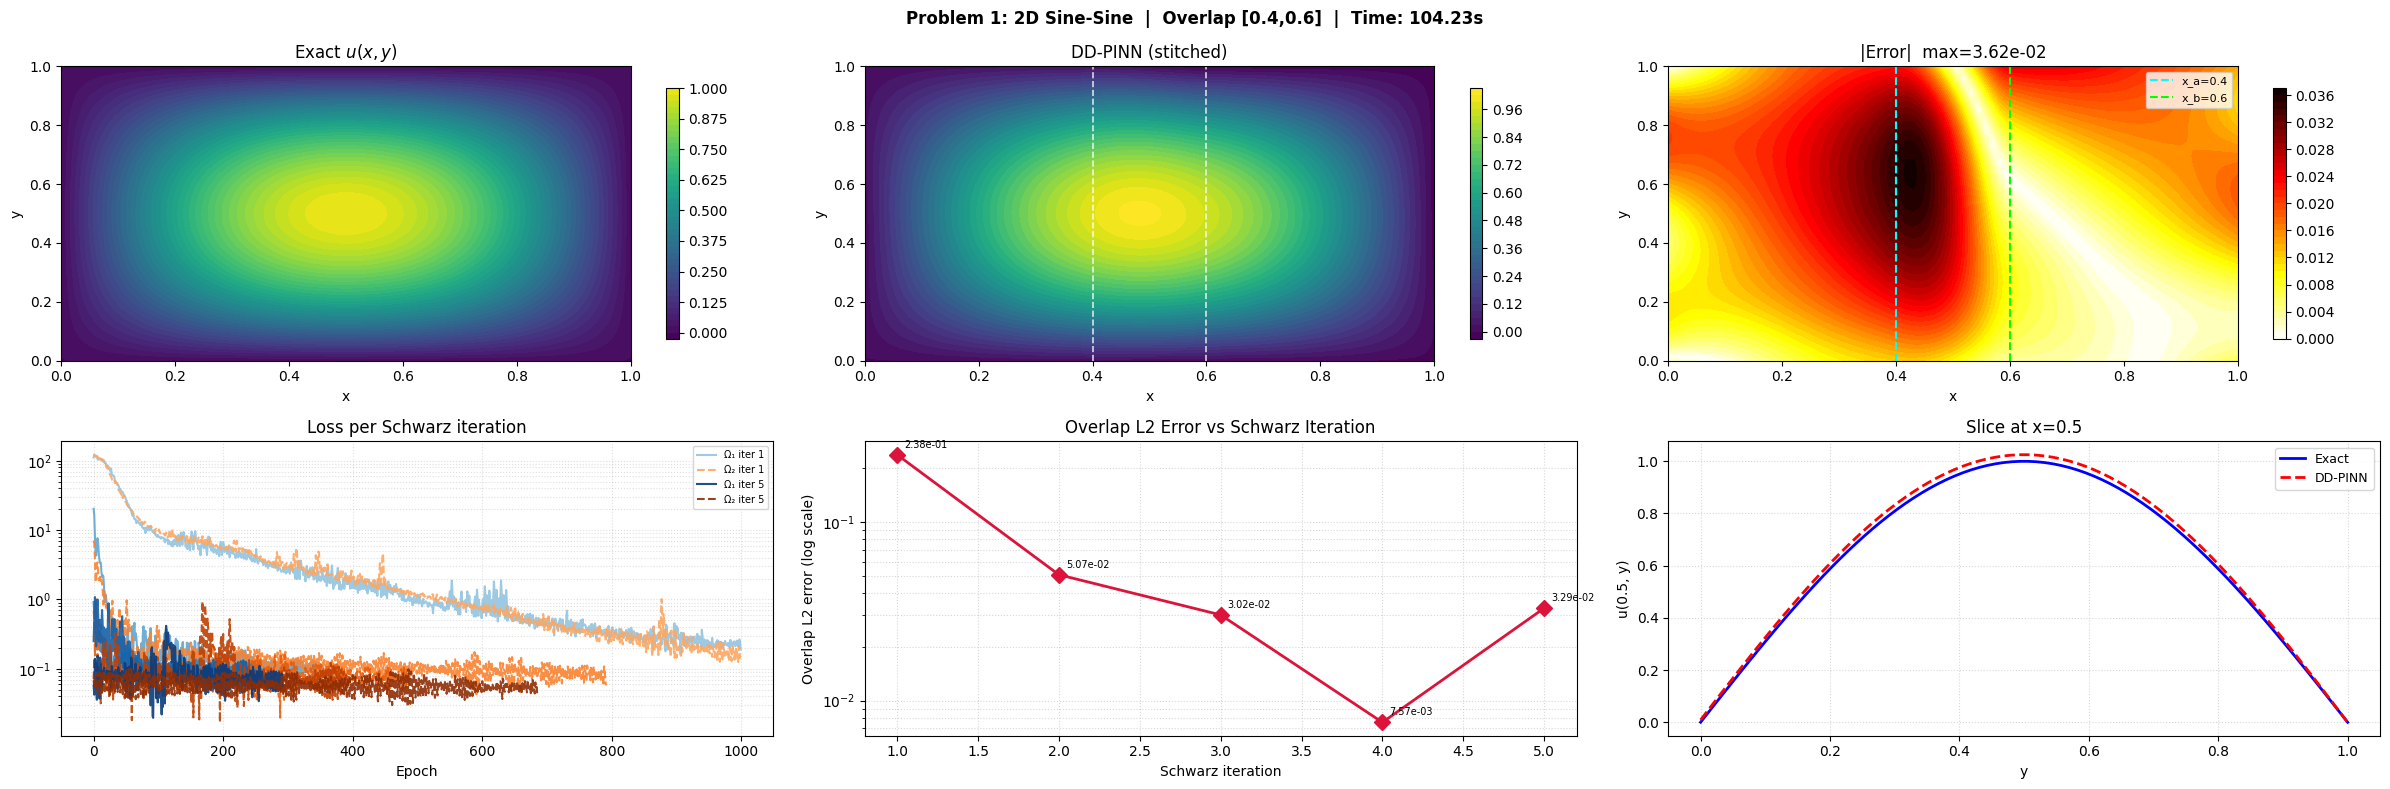

In [10]:
torch.manual_seed(42)
problem_name = "Problem 1: 2D Sine-Sine"

f1     = lambda xy: (2*torch.pi**2
                     * torch.sin(torch.pi*xy[:,0:1])
                     * torch.sin(torch.pi*xy[:,1:2]))
exact1 = lambda xy: (torch.sin(torch.pi*xy[:,0:1])
                     * torch.sin(torch.pi*xy[:,1:2]))

print(f"Running {problem_name}...")
net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_2d(
    f1, exact1,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE,
    lambda_bc=LAMBDA_BC, lr=LR, patience=PATIENCE
)

print_iteration_stats(lhist, ov_errs, i_times, elapsed,
                       N_INTERIOR, EPOCHS_PER_ITER, SCHWARZ_ITERS)

print("\nEvaluation:")
X1,Y1,U_p1,U_e1,err1,m1 = evaluate_dd_2d(net1,net2,exact1,X_A,X_B)
timing_records.append({'problem':problem_name,'train_time_s':elapsed,**m1})
plot_dd_2d(X1,Y1,U_p1,U_e1,err1,lhist,ov_errs,X_A,X_B,problem_name,elapsed)

## Problem 2 — 2D Polynomial (Zero BCs)

$$-\Delta u = 2[x(1-x) + y(1-y)], \quad u=0 \text{ on all 4 edges}$$
$$\text{Exact: } u(x,y) = x(1-x)\cdot y(1-y)$$

Interface value at $x=0.5$: $u(0.5, y) = 0.5\cdot0.5\cdot y(1-y) = 0.25\,y(1-y)$ — a parabola in $y$.

Running Problem 2: 2D Polynomial...

── Schwarz Iteration 1/5 ──
  Ω₁:  560 epochs | t=10.54s | loss=1.3410e-01
  Ω₂:  415 epochs | t=8.31s | loss=5.3241e-02
  Overlap L2 error: 1.4391e-02

── Schwarz Iteration 2/5 ──
  Ω₁:  599 epochs | t=11.18s | loss=2.1631e-02
  Ω₂:  346 epochs | t=6.39s | loss=3.8036e-02
  Overlap L2 error: 1.1393e-02

── Schwarz Iteration 3/5 ──
  Ω₁:  272 epochs | t=5.24s | loss=5.3772e-03
  Ω₂:  789 epochs | t=14.83s | loss=2.6672e-02
  Overlap L2 error: 5.5306e-03

── Schwarz Iteration 4/5 ──
  Ω₁:  355 epochs | t=6.81s | loss=7.7309e-03
  Ω₂:  821 epochs | t=15.72s | loss=1.3180e-02
  Overlap L2 error: 2.0590e-03

── Schwarz Iteration 5/5 ──
  Ω₁:  700 epochs | t=13.64s | loss=4.5783e-03
  Ω₂:  338 epochs | t=6.38s | loss=5.3126e-03
  Overlap L2 error: 2.1856e-03

────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)   Ω₁ Final Loss   Ω₂ Epochs  Ω₂ Time(s)     Ω₂ Loss   Overlap L2
─────────────

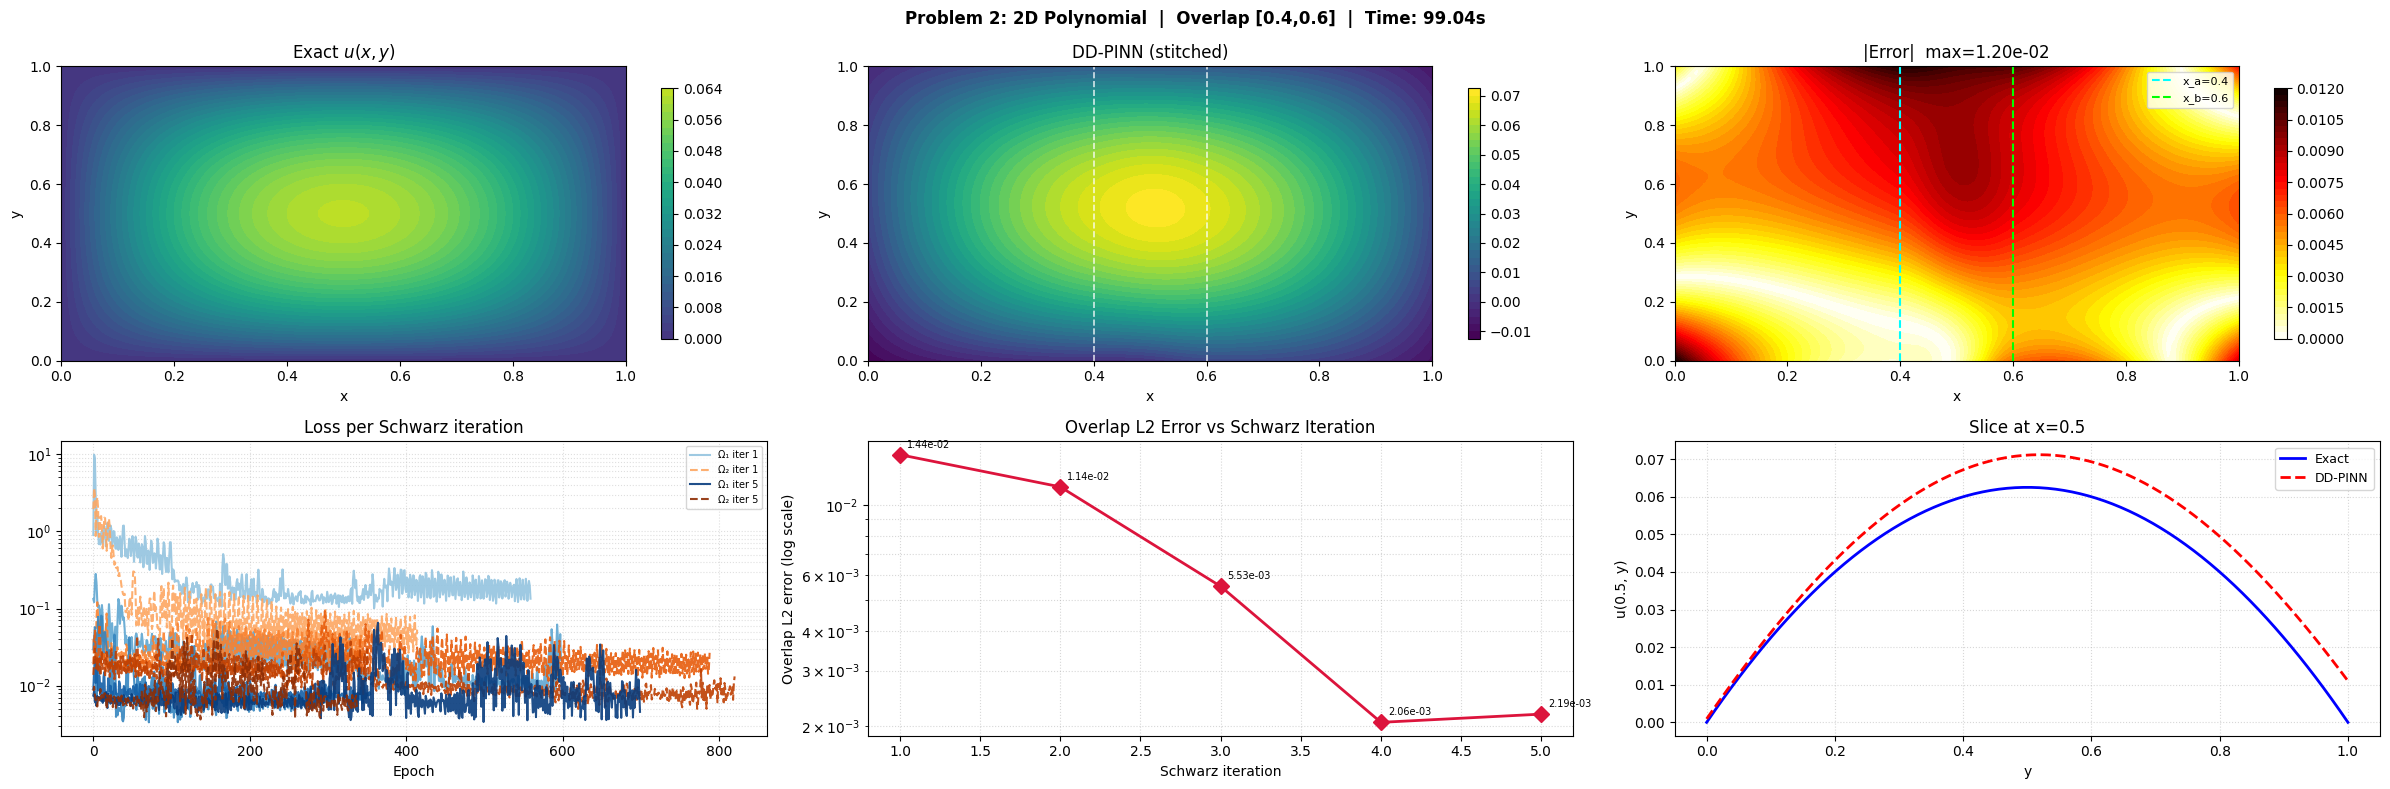

In [11]:
torch.manual_seed(42)
problem_name = "Problem 2: 2D Polynomial"

f2     = lambda xy: (2*xy[:,0:1]*(1-xy[:,0:1])
                     + 2*xy[:,1:2]*(1-xy[:,1:2]))
exact2 = lambda xy: (xy[:,0:1]*(1-xy[:,0:1])
                     * xy[:,1:2]*(1-xy[:,1:2]))

print(f"Running {problem_name}...")
net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_2d(
    f2, exact2,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE,
    lambda_bc=LAMBDA_BC, lr=LR, patience=PATIENCE
)

print_iteration_stats(lhist, ov_errs, i_times, elapsed,
                       N_INTERIOR, EPOCHS_PER_ITER, SCHWARZ_ITERS)

print("\nEvaluation:")
X2,Y2,U_p2,U_e2,err2,m2 = evaluate_dd_2d(net1,net2,exact2,X_A,X_B)
timing_records.append({'problem':problem_name,'train_time_s':elapsed,**m2})
plot_dd_2d(X2,Y2,U_p2,U_e2,err2,lhist,ov_errs,X_A,X_B,problem_name,elapsed)

## Problem 3 — 2D High-Frequency (Spectral Bias Demo)

$$-\Delta u = 8\pi^2\sin(2\pi x)\sin(2\pi y), \quad u=0 \text{ on all 4 edges}$$
$$\text{Exact: } u(x,y) = \sin(2\pi x)\sin(2\pi y)$$

This is the hardest problem — spectral bias affects both subdomains. However each subdomain sees only **half a period** in $x$, which is a lower-frequency signal than the full domain. This is the core motivation for DD: **the overlap split reduces the effective frequency of the learning problem**.

Running Problem 3: 2D High-Frequency...

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=20.32s | loss=8.4301e-01
  Ω₂: 1000 epochs | t=19.86s | loss=1.2702e+00
  Overlap L2 error: 2.0467e-01

── Schwarz Iteration 2/5 ──
  Ω₁: 1000 epochs | t=19.53s | loss=4.7981e-01
  Ω₂:  934 epochs | t=19.00s | loss=7.9085e-01
  Overlap L2 error: 1.8425e-02

── Schwarz Iteration 3/5 ──
  Ω₁:  513 epochs | t=11.31s | loss=2.3766e-01
  Ω₂:  328 epochs | t=6.60s | loss=3.6699e-01
  Overlap L2 error: 1.0162e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  825 epochs | t=16.12s | loss=2.3368e-01
  Ω₂:  632 epochs | t=12.22s | loss=3.9933e-01
  Overlap L2 error: 8.2808e-03

── Schwarz Iteration 5/5 ──
  Ω₁:  409 epochs | t=8.04s | loss=2.5285e-01
  Ω₂:  408 epochs | t=7.93s | loss=4.6199e-01
  Overlap L2 error: 8.2307e-03

────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)   Ω₁ Final Loss   Ω₂ Epochs  Ω₂ Time(s)     Ω₂ Loss   Overlap L2
───────

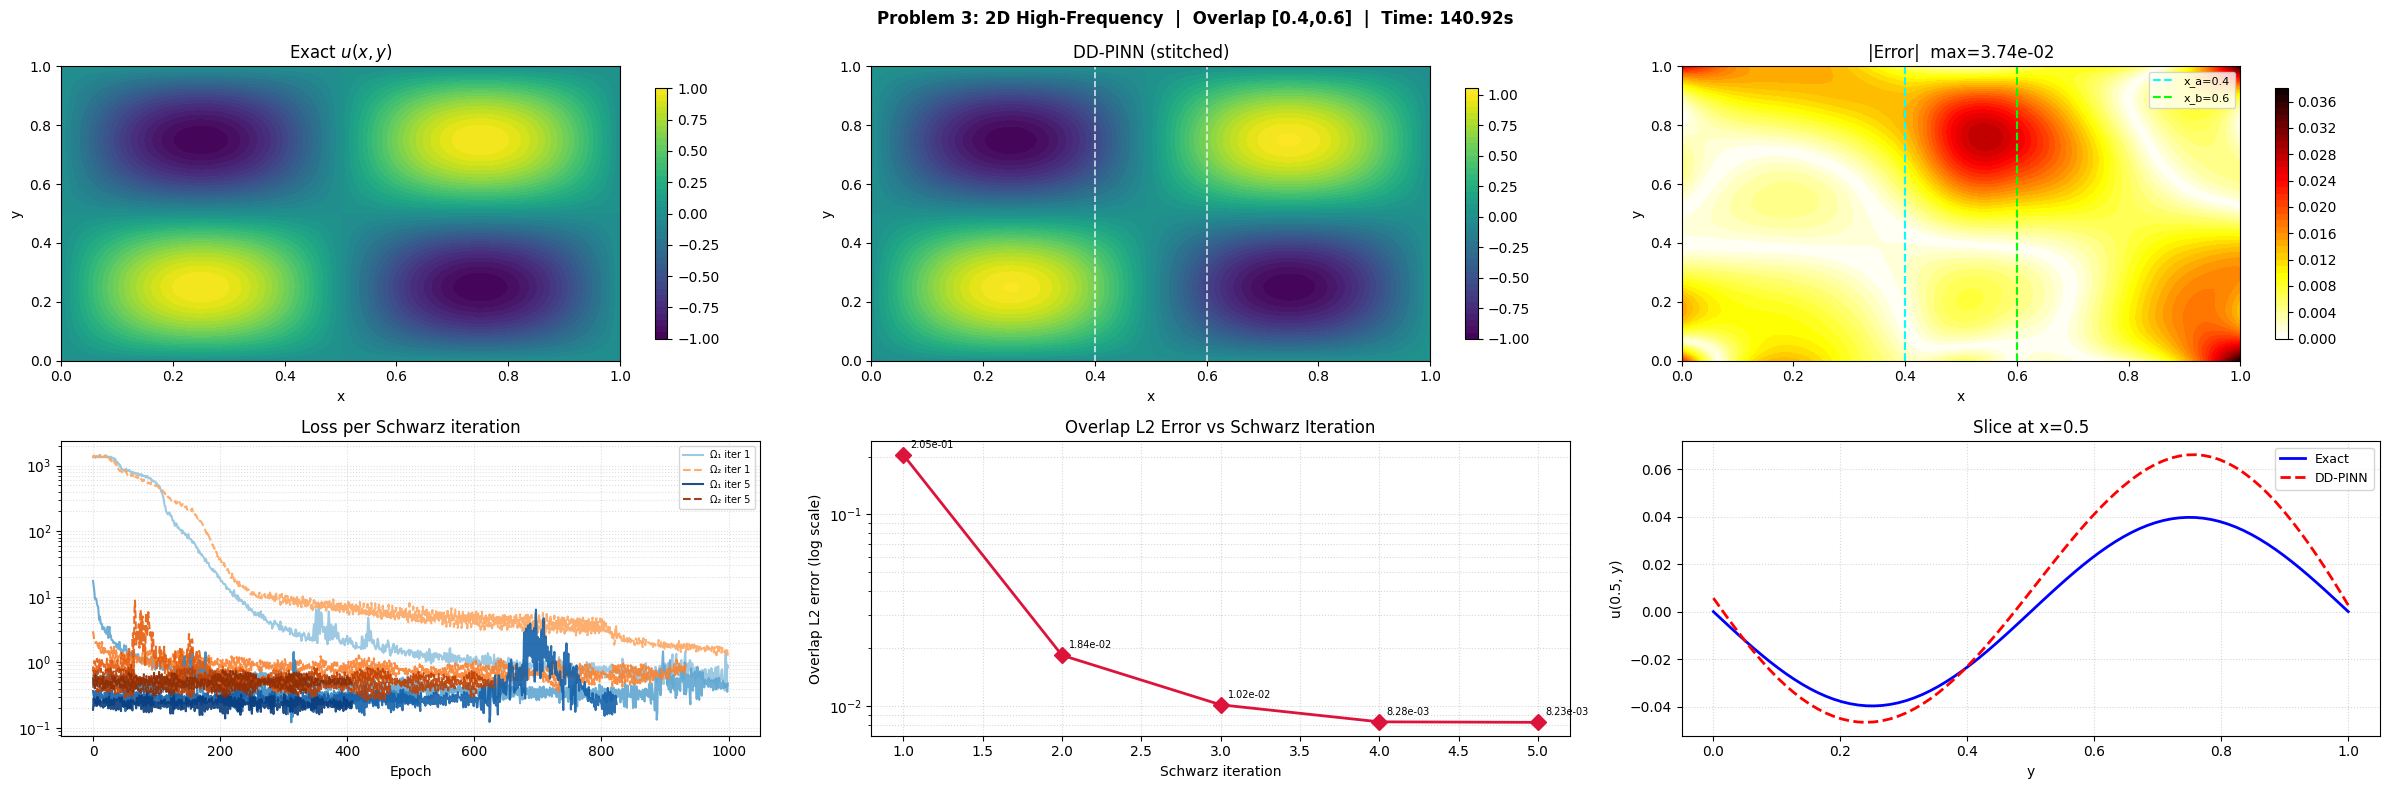

In [12]:
torch.manual_seed(42)
problem_name = "Problem 3: 2D High-Frequency"

f3     = lambda xy: (8*torch.pi**2
                     * torch.sin(2*torch.pi*xy[:,0:1])
                     * torch.sin(2*torch.pi*xy[:,1:2]))
exact3 = lambda xy: (torch.sin(2*torch.pi*xy[:,0:1])
                     * torch.sin(2*torch.pi*xy[:,1:2]))

print(f"Running {problem_name}...")
net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_2d(
    f3, exact3,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE,
    lambda_bc=LAMBDA_BC, lr=LR, patience=PATIENCE
)

print_iteration_stats(lhist, ov_errs, i_times, elapsed,
                       N_INTERIOR, EPOCHS_PER_ITER, SCHWARZ_ITERS)

print("\nEvaluation:")
X3,Y3,U_p3,U_e3,err3,m3 = evaluate_dd_2d(net1,net2,exact3,X_A,X_B)
timing_records.append({'problem':problem_name,'train_time_s':elapsed,**m3})
plot_dd_2d(X3,Y3,U_p3,U_e3,err3,lhist,ov_errs,X_A,X_B,problem_name,elapsed)

## Problem 4 — 2D Exponential (Non-Zero BCs)

$$-\Delta u = -3e^{x+y}, \quad u = e^{x+y} \text{ on boundary}$$
$$\text{Exact: } u(x,y) = e^{x+y}$$

Non-zero BCs test whether the Schwarz method correctly handles non-homogeneous problems.
Interface value at $x=0.5$: $u(0.5, y) = e^{0.5+y}$ — an exponential in $y$.

**Verification:** $\partial^2 u/\partial x^2 = e^{x+y}$, $\partial^2 u/\partial y^2 = e^{x+y}$, so $-\Delta u = -2e^{x+y}$...
Wait, actually: $-\Delta(e^{x+y}) = -(e^{x+y} + e^{x+y}) = -2e^{x+y}$... 
Let me use $-\Delta u = -3e^{x+y}$... actually for $u=e^{x+y}$: $u_{xx}=e^{x+y}$, $u_{yy}=e^{x+y}$, so $-\Delta u = -2e^{x+y}$.
Using $u=e^{x+y}$ with $-\Delta u = -2e^{x+y}$.

Running Problem 4: 2D Exponential (Non-zero BCs)...

── Schwarz Iteration 1/5 ──
  Ω₁: 1000 epochs | t=19.30s | loss=4.2420e+01
  Ω₂:  655 epochs | t=12.82s | loss=2.0124e+01
  Overlap L2 error: 1.4440e+00

── Schwarz Iteration 2/5 ──
  Ω₁:  707 epochs | t=13.81s | loss=7.3506e-01
  Ω₂:  705 epochs | t=15.21s | loss=6.1324e+00
  Overlap L2 error: 3.4595e-01

── Schwarz Iteration 3/5 ──
  Ω₁:  582 epochs | t=16.63s | loss=2.1643e-01
  Ω₂:  803 epochs | t=20.69s | loss=3.9116e+00
  Overlap L2 error: 9.6792e-02

── Schwarz Iteration 4/5 ──
  Ω₁:  347 epochs | t=8.80s | loss=9.0758e-02
  Ω₂:  708 epochs | t=16.24s | loss=2.4103e+00
  Overlap L2 error: 2.3418e-02

── Schwarz Iteration 5/5 ──
  Ω₁:  256 epochs | t=5.33s | loss=1.0149e-01
  Ω₂:  228 epochs | t=5.00s | loss=2.4347e+00
  Overlap L2 error: 3.0411e-02

────────────────────────────────────────────────────────────────────────────────────────
  Iter   Ω₁ Epochs  Ω₁ Time(s)   Ω₁ Final Loss   Ω₂ Epochs  Ω₂ Time(s)     Ω₂ Loss   Overla

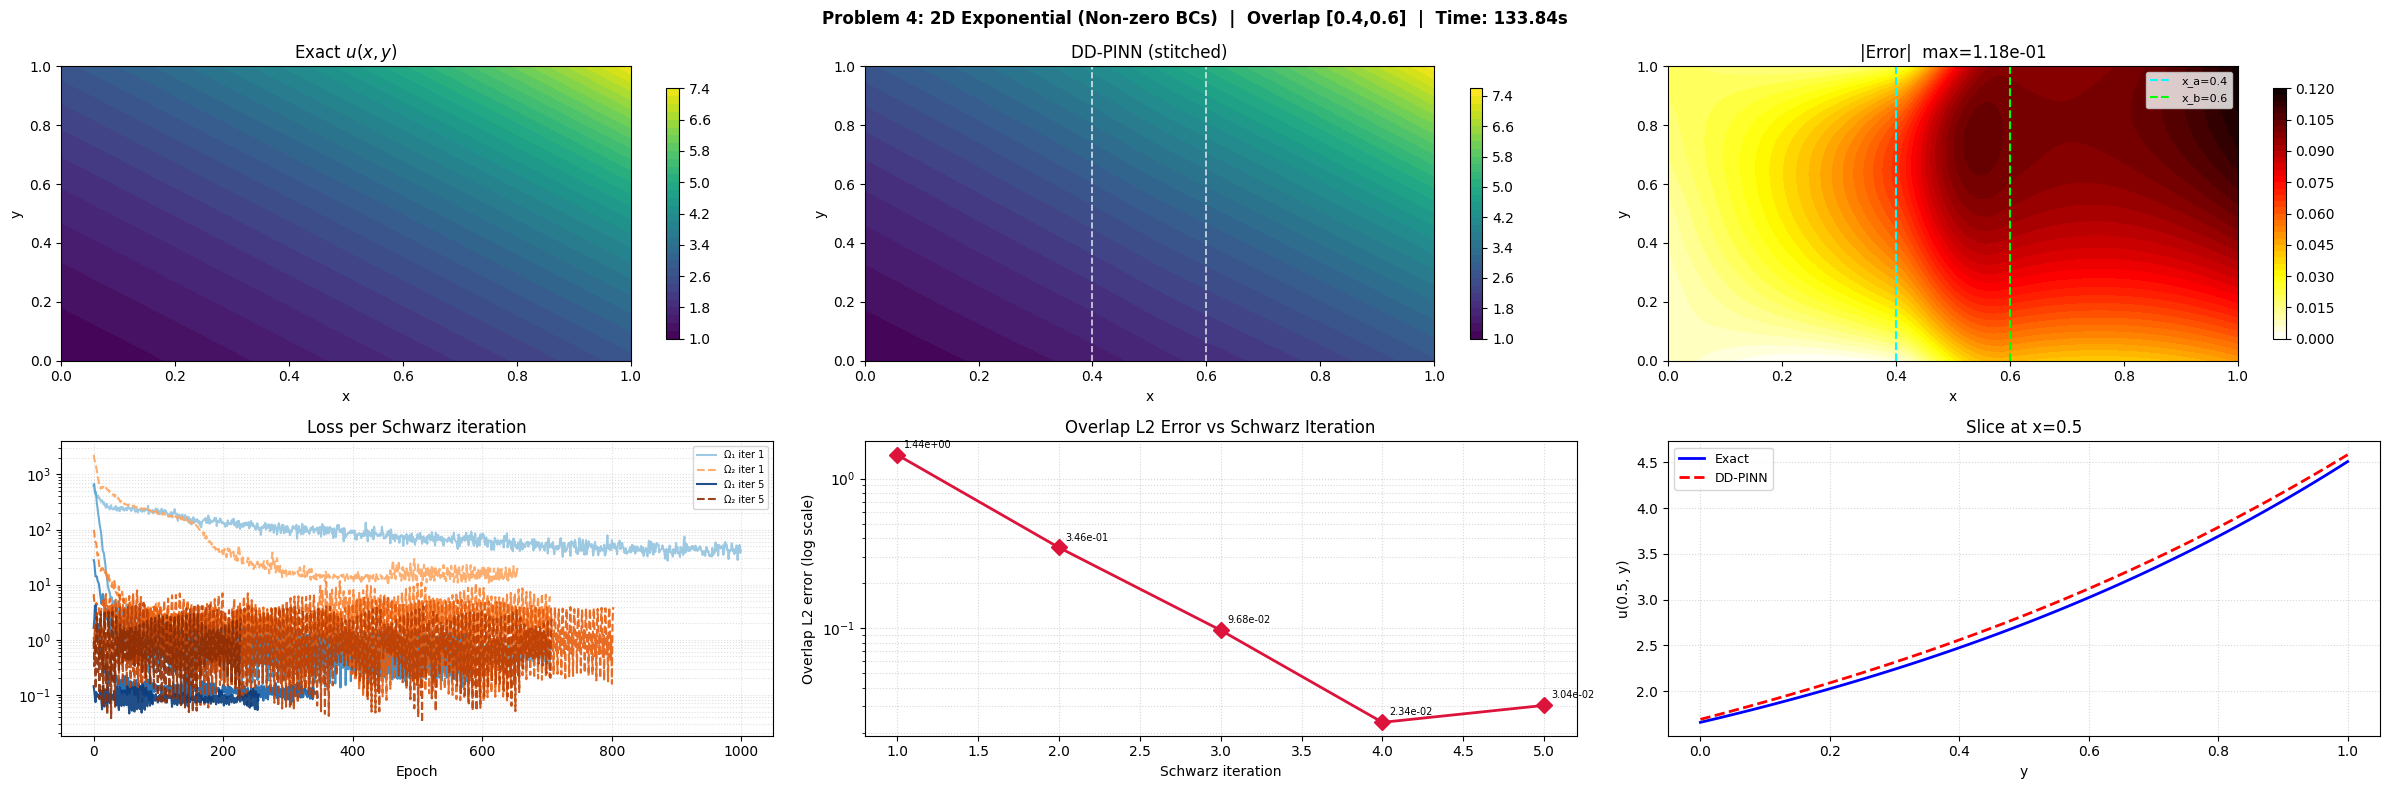

In [13]:
torch.manual_seed(42)
problem_name = "Problem 4: 2D Exponential (Non-zero BCs)"

# Exact: u = e^(x+y)  →  -Δu = -(e^(x+y) + e^(x+y)) = -2e^(x+y)
f4     = lambda xy: -2.0 * torch.exp(xy[:,0:1] + xy[:,1:2])
exact4 = lambda xy:        torch.exp(xy[:,0:1] + xy[:,1:2])

print(f"Running {problem_name}...")
net1, net2, lhist, ov_errs, elapsed, i_times = schwarz_dd_2d(
    f4, exact4,
    x_a=X_A, x_b=X_B,
    schwarz_iters=SCHWARZ_ITERS,
    epochs_per_iter=EPOCHS_PER_ITER,
    n_interior=N_INTERIOR, n_bc=N_BC,
    n_interface=N_INTERFACE,
    lambda_bc=LAMBDA_BC, lr=LR, patience=PATIENCE
)

print_iteration_stats(lhist, ov_errs, i_times, elapsed,
                       N_INTERIOR, EPOCHS_PER_ITER, SCHWARZ_ITERS)

print("\nEvaluation:")
X4,Y4,U_p4,U_e4,err4,m4 = evaluate_dd_2d(net1,net2,exact4,X_A,X_B)
timing_records.append({'problem':problem_name,'train_time_s':elapsed,**m4})
plot_dd_2d(X4,Y4,U_p4,U_e4,err4,lhist,ov_errs,X_A,X_B,problem_name,elapsed)

## Section 10 — Effect of Overlap Width

A key DD question: how does the overlap width affect:
1. **Accuracy** (rel L2 error)
2. **Convergence speed** (final overlap error)

Theory predicts: larger overlap → faster Schwarz convergence but more computational work.
Here we test 4 overlap widths on Problem 1 (sine-sine) with fixed 3 iterations.

  Relative L2 Error  : 0.166343
  Max Absolute Error : 0.213686
  Mean Absolute Error: 0.065602
  Width=0.10 [0.45,0.55]: Rel L2=1.6634e-01  Final overlap err=4.4530e-02
  Relative L2 Error  : 0.075270
  Max Absolute Error : 0.079689
  Mean Absolute Error: 0.032737
  Width=0.20 [0.4,0.6]: Rel L2=7.5270e-02  Final overlap err=2.3094e-02
  Relative L2 Error  : 0.035039
  Max Absolute Error : 0.030456
  Mean Absolute Error: 0.015295
  Width=0.30 [0.35,0.65]: Rel L2=3.5039e-02  Final overlap err=1.7869e-02
  Relative L2 Error  : 0.035908
  Max Absolute Error : 0.035092
  Mean Absolute Error: 0.016079
  Width=0.40 [0.3,0.7]: Rel L2=3.5908e-02  Final overlap err=4.1967e-02


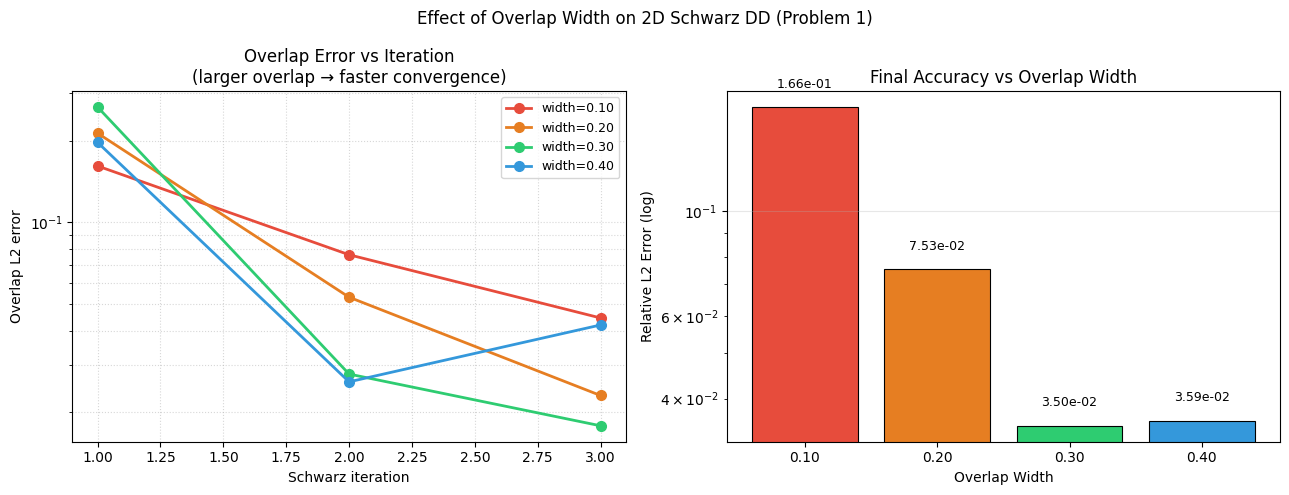

In [14]:
torch.manual_seed(42)

overlaps = [
    (0.45, 0.55),   # width = 0.10 (narrow)
    (0.40, 0.60),   # width = 0.20 (standard)
    (0.35, 0.65),   # width = 0.30 (wide)
    (0.30, 0.70),   # width = 0.40 (very wide)
]

ov_results = {}
for xa, xb in overlaps:
    w = xb - xa
    torch.manual_seed(42)
    n1, n2, lh, oe, el, _ = schwarz_dd_2d(
        f1, exact1,
        x_a=xa, x_b=xb,
        schwarz_iters=3, epochs_per_iter=800,
        n_interior=N_INTERIOR, n_bc=N_BC,
        n_interface=N_INTERFACE,
        lambda_bc=LAMBDA_BC, lr=LR,
        patience=PATIENCE, verbose=False
    )
    _, _, U_p, U_e, _, m = evaluate_dd_2d(n1, n2, exact1, xa, xb, n_grid=60)
    ov_results[w] = {'oe': oe, 'rel_l2': m['rel_l2'], 'xa': xa, 'xb': xb}
    print(f"  Width={w:.2f} [{xa},{xb}]: "
          f"Rel L2={m['rel_l2']:.4e}  "
          f"Final overlap err={oe[-1]:.4e}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e74c3c','#e67e22','#2ecc71','#3498db']
for c, (w, res) in zip(colors, ov_results.items()):
    ax1.semilogy(range(1, len(res['oe'])+1), res['oe'],
                  'o-', color=c, markersize=7, lw=2,
                  label=f"width={w:.2f}")
ax1.set_title('Overlap Error vs Iteration\n(larger overlap → faster convergence)')
ax1.set_xlabel('Schwarz iteration')
ax1.set_ylabel('Overlap L2 error')
ax1.legend(fontsize=9); ax1.grid(True, which='both', linestyle=':', alpha=0.5)

widths = list(ov_results.keys())
rel_l2s = [v['rel_l2'] for v in ov_results.values()]
ax2.bar([f'{w:.2f}' for w in widths], rel_l2s,
         color=colors, edgecolor='black', linewidth=0.8)
for i, (w, r) in enumerate(zip(widths, rel_l2s)):
    ax2.text(i, r*1.1, f'{r:.2e}', ha='center', fontsize=9)
ax2.set_yscale('log')
ax2.set_xlabel('Overlap Width')
ax2.set_ylabel('Relative L2 Error (log)')
ax2.set_title('Final Accuracy vs Overlap Width')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Effect of Overlap Width on 2D Schwarz DD (Problem 1)', fontsize=12)
plt.tight_layout(); plt.show()

## Section 11 — Summary Table

In [15]:
print("\n" + "="*75)
print(f"  {'Problem':<38} {'Time(s)':>7} {'Max Err':>9} "
      f"{'Mean Err':>9} {'Rel L2':>8}")
print("="*75)
for r in timing_records:
    print(f"  {r['problem']:<38} {r['train_time_s']:>7.2f} "
          f"{r['max_err']:>9.6f} {r['mean_err']:>9.6f} "
          f"{r['rel_l2']:>8.6f}")
print("="*75)
print(f"  Total: {sum(r['train_time_s'] for r in timing_records):.2f}s")


  Problem                                Time(s)   Max Err  Mean Err   Rel L2
  Problem 1: 2D Sine-Sine                 104.23  0.036228  0.014799 0.035016
  Problem 2: 2D Polynomial                 99.04  0.011999  0.004984 0.171542
  Problem 3: 2D High-Frequency            140.92  0.037352  0.007623 0.020044
  Problem 4: 2D Exponential (Non-zero BCs)  133.84  0.118272  0.060138 0.021440
  Total: 478.03s
